# BREAST CANCER ANALYSIS AND PREDICTION USING DATA ANALYTICS

## INTRODUCTION

Breast cancer is one of the most common diseases affecting women worldwide. Early detection and diagnosis play a crucial role in improving survival rates.

In this project, we analyze breast cancer data using data analytics techniques and build machine learning models to predict whether a tumor is benign or malignant.

## IMPORT THE REQUIRED LIBRARIES



In this step, the required libraries for data analysis, visualization, and machine learning are imported.

**pandas** is used for data manipulation and analysis  
**NumPy** is used for numerical operations  
**Matplotlib** and **Seaborn** are used for data visualization  
**Scikit-learn** is used for building machine learning models  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

## Loading the Dataset


In [2]:
df=pd.read_csv(r"C:\Users\sunev\Downloads\breast_cancer.csv")
print(df.head(4))

   Clump Thickness  Uniformity of Cell Size  Uniformity of Cell Shape  \
0                5                        1                         1   
1                5                        4                         4   
2                3                        1                         1   
3                6                        8                         8   

   Marginal Adhesion  Single Epithelial Cell Size  Bare Nuclei  \
0                  1                            2            1   
1                  5                            7           10   
2                  1                            2            2   
3                  1                            3            4   

   Bland Chromatin  Normal Nucleoli  Mitoses  Class  
0                3                1        1      2  
1                3                2        1      2  
2                3                1        1      2  
3                3                7        1      2  


## DATA UNDERSTANDING
Understanding the dataset helps identify its structure, features, and data types.



In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 683 entries, 0 to 682
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Clump Thickness              683 non-null    int64
 1   Uniformity of Cell Size      683 non-null    int64
 2   Uniformity of Cell Shape     683 non-null    int64
 3   Marginal Adhesion            683 non-null    int64
 4   Single Epithelial Cell Size  683 non-null    int64
 5   Bare Nuclei                  683 non-null    int64
 6   Bland Chromatin              683 non-null    int64
 7   Normal Nucleoli              683 non-null    int64
 8   Mitoses                      683 non-null    int64
 9   Class                        683 non-null    int64
dtypes: int64(10)
memory usage: 53.5 KB


In [4]:
df.describe()

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
count,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000
mean,4.442167,3.150805,3.215227,2.830161,3.234261,3.544656,3.445095,2.869693,1.603221,2.699854
std,2.820761,3.065145,2.988581,2.864562,2.223085,3.643857,2.449697,3.052666,1.732674,0.954592
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,2.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000,4.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


In [5]:
df.shape

(683, 10)

In [6]:
df.columns

Index(['Clump Thickness', 'Uniformity of Cell Size',
       'Uniformity of Cell Shape', 'Marginal Adhesion',
       'Single Epithelial Cell Size', 'Bare Nuclei', 'Bland Chromatin',
       'Normal Nucleoli', 'Mitoses', 'Class'],
      dtype='object')

## DATA CLEANING

This step involves handling missing values and correcting data to improve data quality.


checking missing values

In [7]:
df.isnull().sum()


Clump Thickness                0
Uniformity of Cell Size        0
Uniformity of Cell Shape       0
Marginal Adhesion              0
Single Epithelial Cell Size    0
Bare Nuclei                    0
Bland Chromatin                0
Normal Nucleoli                0
Mitoses                        0
Class                          0
dtype: int64

there is no longer missing value in data set

step2:checking duplicates

In [8]:
df.duplicated().sum()

np.int64(234)

In [9]:
df.drop_duplicates()

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,2
1,5,4,4,5,7,10,3,2,1,2
2,3,1,1,1,2,2,3,1,1,2
3,6,8,8,1,3,4,3,7,1,2
4,4,1,1,3,2,1,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...
677,3,1,1,1,2,1,2,1,2,2
678,3,1,1,1,3,2,1,1,1,2
680,5,10,10,3,7,3,8,10,2,4
681,4,8,6,4,3,4,10,6,1,4


In [10]:
df=df.drop_duplicates()

In [11]:
df.duplicated().sum()

np.int64(0)

<h2 style="font-weight:bold;">EXPLORATORY DATA ANALYSIS</h2>

<p style="font-size:16px;">
Exploratory Data Analysis (EDA) is the process of analyzing and understanding the dataset to discover patterns, relationships, and insights. In this step, we use statistical methods and visualizations to examine how different features such as a class,count,
</p>

<p style="font-size:16px;">
EDA helps in identifying important variables, detecting anomalies, and gaining meaningful insights before building a machine learning model.
</p>


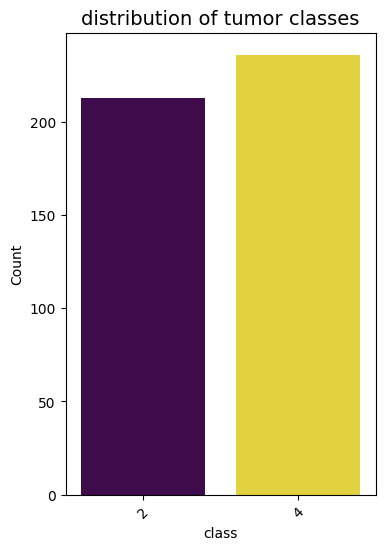

In [12]:
#1 What is the distribution of tumor classes in the dataset?
class_counts = df['Class'].value_counts().reset_index()
class_counts.columns = ['class', 'Count']
plt.figure(figsize=(4, 6))
sns.barplot(x='class', y='Count', data=class_counts, palette='viridis', hue='class', legend=False)
plt.title("distribution of tumor classes", fontsize=14)
plt.xlabel("class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

The tumor class distribution shows that the dataset does not suffer from severe class imbalance, making it suitable for classification tasks.

In [13]:
#2 What is the average Clump Thickness in the dataset?
a=df["Clump Thickness"].mean()
print("average thickness",a)

average thickness 5.378619153674833




The average **Clump Thickness** in the dataset gives a general idea of the typical cell thickness observed in the samples. A moderate average value suggests that most cases fall around the middle range, helping us understand the overall distribution of this feature in tumor classification.


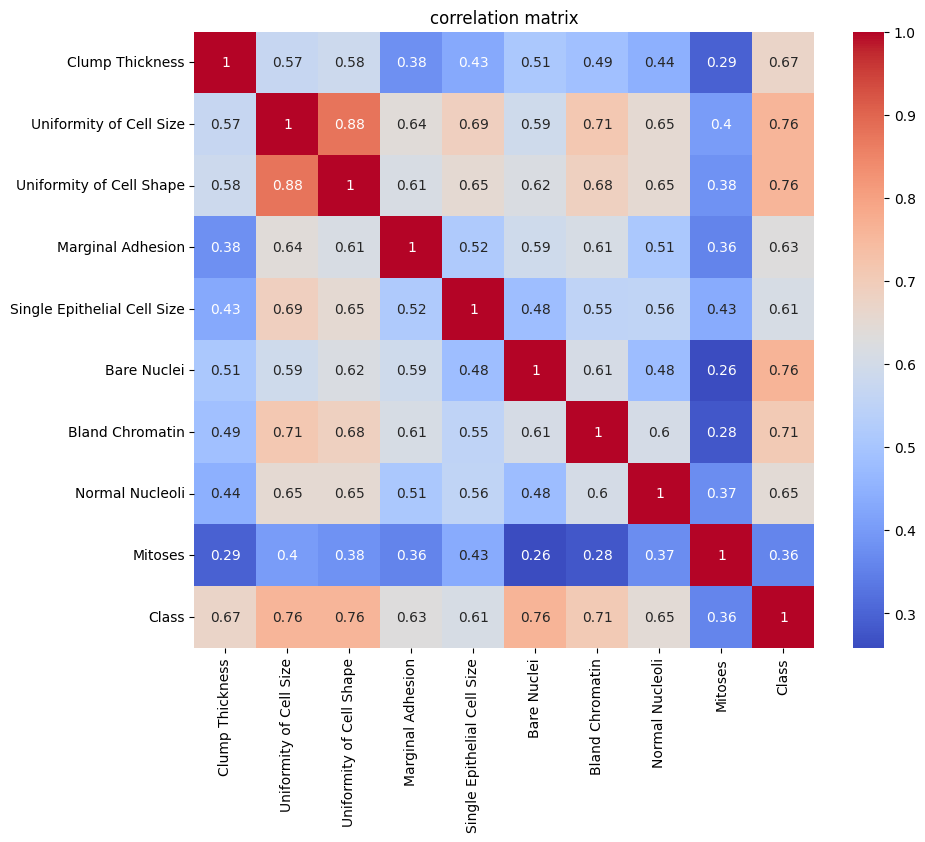

In [14]:
#3 What is the correlation between all numerical features?
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.title("correlation matrix")
plt.show()



The correlation heatmap helps show the relationship between all numerical features in the dataset. Strong positive values mean features increase together, while negative values mean they move in opposite directions. This helps in identifying important features for classification.


The heatmap indicates that cell size, cell shape, and bare nuclei are strongly related to tumor classification, suggesting these features are important predictors for identifying tumor type.

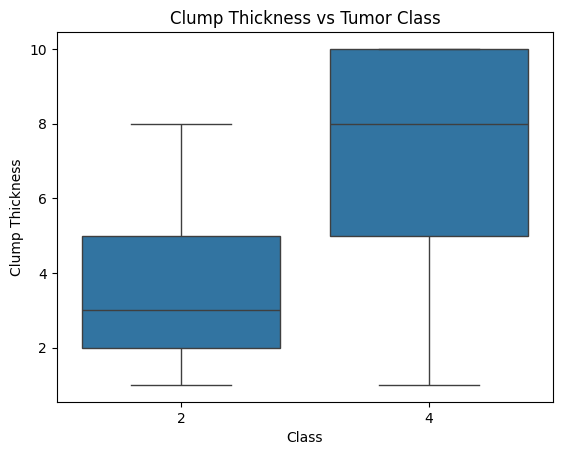

In [15]:
#4 How does Clump Thickness vary between benign and malignant tumors?
sns.boxplot(x='Class', y='Clump Thickness', data=df)
plt.title("Clump Thickness vs Tumor Class")
plt.show()

Clump Thickness tends to be much higher in malignant tumors compared to benign tumors. This suggests that Clump Thickness is an important feature for distinguishing between benign and malignant tumor classes.

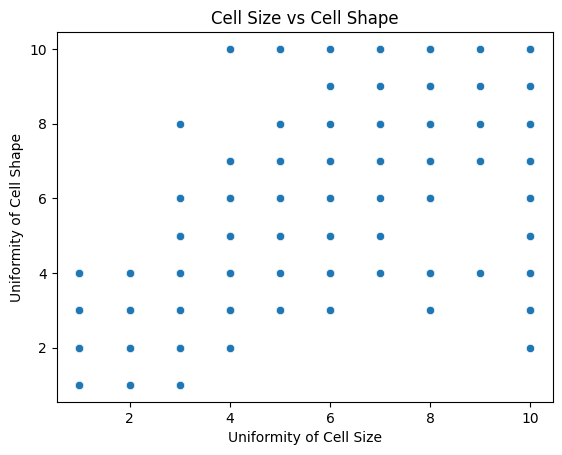

In [16]:
#5 What is the relationship between Uniformity of Cell Size and Uniformity of Cell Shape?
sns.scatterplot(x='Uniformity of Cell Size', y='Uniformity of Cell Shape', data=df)
plt.title("Cell Size vs Cell Shape")
plt.show()

There is a strong positive correlation between Uniformity of Cell Size and Uniformity of Cell Shape. This suggests that tumors with irregular cell sizes often also have irregular cell shapes, making these features important indicators in tumor classification.

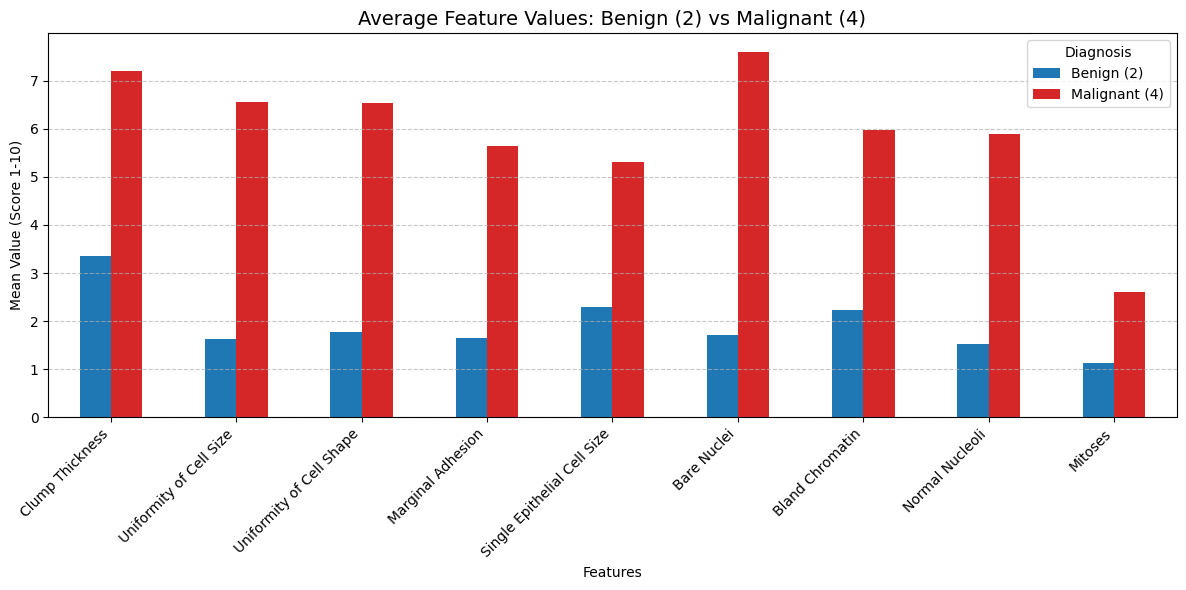

In [17]:
#6What is the average value of every feature for Benign (2) vs Malignant ?
class_means = df.groupby('Class').mean()
class_means.T.plot(kind='bar', figsize=(12, 6), color=['#1f77b4', '#d62728'])
plt.title('Average Feature Values: Benign (2) vs Malignant (4)', fontsize=14)
plt.ylabel('Mean Value (Score 1-10)')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.legend(['Benign (2)', 'Malignant (4)'], title='Diagnosis')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



The bar chart shows that malignant tumors have higher average values for most features compared to benign tumors. This indicates that these features play an important role in distinguishing between benign and malignant cases.

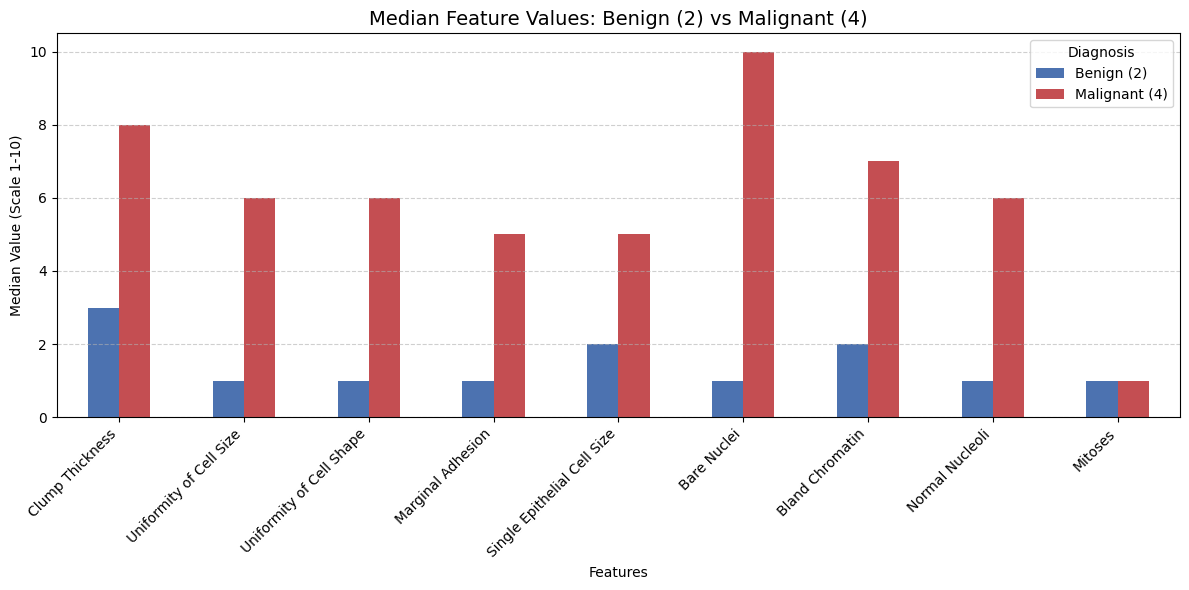

In [18]:
#7. What is the median value of each feature for each class?
class_medians = df.groupby('Class').median()
class_medians.T.plot(kind='bar', figsize=(12, 6), color=['#4C72B0', '#C44E52'])
plt.title('Median Feature Values: Benign (2) vs Malignant (4)', fontsize=14)
plt.ylabel('Median Value (Scale 1-10)')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.legend(['Benign (2)', 'Malignant (4)'], title='Diagnosis')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()




The median values of most features are higher for malignant tumors than for benign tumors. This shows that malignant cases generally have stronger feature values, making classification easier.


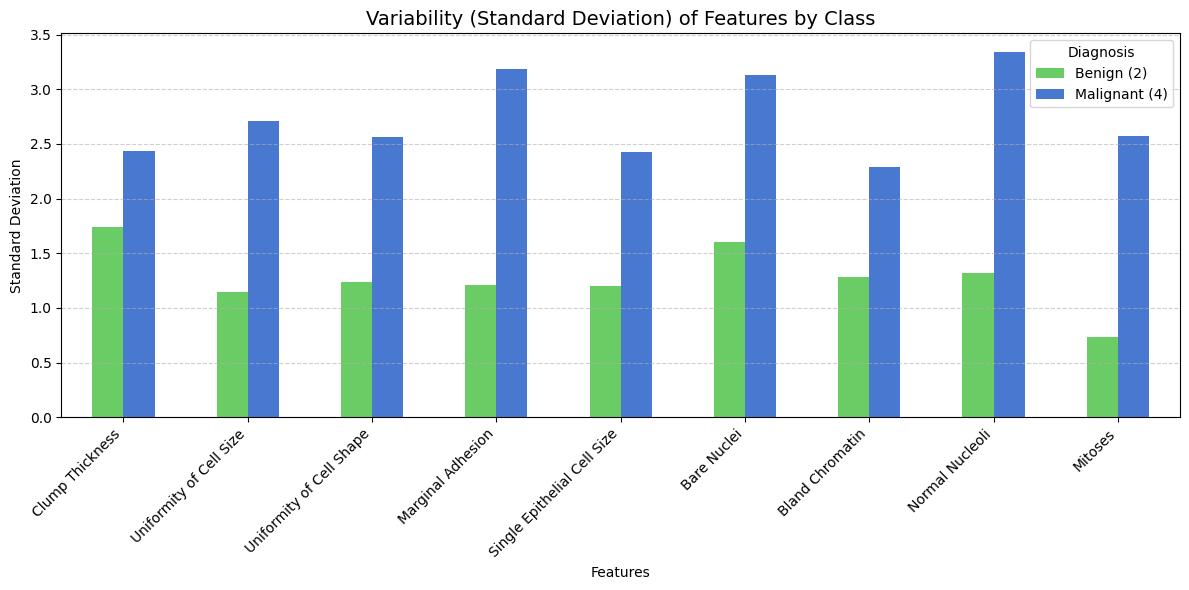

In [19]:
#8. What is the median value of each feature for each class?
class_std = df.groupby('Class').std()
class_std.T.plot(kind='bar', figsize=(12, 6), color=['#6acc64', '#4878d0'])
plt.title('Variability (Standard Deviation) of Features by Class', fontsize=14)
plt.ylabel('Standard Deviation')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.legend(['Benign (2)', 'Malignant (4)'], title='Diagnosis')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



The standard deviation chart shows how much each feature varies within benign and malignant tumors. Higher variation in some features indicates greater differences among samples, which can help in better classification.


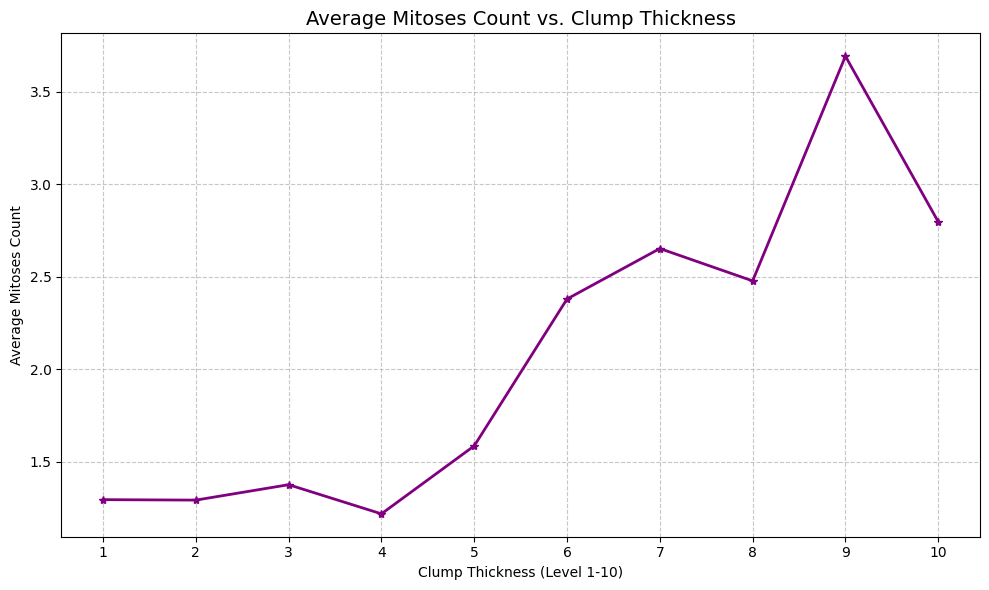

In [20]:
#9 Does the average 'Mitoses' count increase as 'Clump Thickness' increases?
mitoses_by_clump = df.groupby('Clump Thickness')['Mitoses'].mean()
plt.figure(figsize=(10, 6))
mitoses_by_clump.plot(kind='line', marker='*', color='purple', linewidth=2)
plt.title('Average Mitoses Count vs. Clump Thickness', fontsize=14)
plt.xlabel('Clump Thickness (Level 1-10)')
plt.ylabel('Average Mitoses Count')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(range(1, 11)) 
plt.tight_layout()
plt.show()




The line graph shows that the average Mitoses count generally increases as Clump Thickness increases. This suggests a positive relationship between cell thickness and cell division activity, which may indicate higher chances of malignancy.


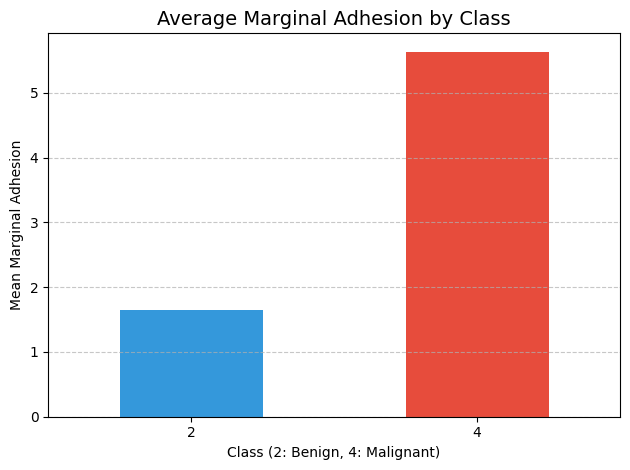

In [21]:
#10. Which class has a higher 'Marginal Adhesion' on average?
mean_adhesion = df.groupby('Class')['Marginal Adhesion'].mean()
mean_adhesion.plot(kind='bar', color=['#3498db', '#e74c3c'])
plt.title('Average Marginal Adhesion by Class', fontsize=14)
plt.xlabel('Class (2: Benign, 4: Malignant)')
plt.ylabel('Mean Marginal Adhesion')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


The bar chart shows that malignant tumors have a higher average Marginal Adhesion than benign tumors. This indicates that Marginal Adhesion is a useful feature for distinguishing between the two classes.

<h2 style="font-weight:bold;">7. TRAIN-TEST SPLIT</h2>

<p style="font-size:16px;">
After preprocessing, the dataset is divided into training and testing sets to evaluate model performance. Features (X) and target (y) are separated, and the split is typically done using an 80%-20% ratio.
</p>

<ul style="font-size:16px;">
  <li>Separate features (X) and target (y)</li>
  <li>Split data into training set and testing set</li>
  <li>Ensure random state for reproducibility</li>
  <li>Scaling is applied only after splitting to avoid data leakage</li>
</ul>

In [22]:
x=df.iloc[:,:-1].values
y=df.iloc[:,-1].values

In [23]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [24]:
sk=StandardScaler()
x_train_scaled=sk.fit_transform(x_train)
x_test_scaled=sk.transform(x_test)


<h2 style="font-weight:bold;">8. MODEL BUILDING & EVALUATION</h2>

<p style="font-size:16px;">
Multiple machine learning models are trained on the preprocessed dataset and evaluated on the test set to measure their performance using key metrics.
</p>

<ul style="font-size:16px;">
  <li>LOGISTIC REGRESSION</li>
  <li>K-NEAREST NEIGHBORS (KNN)</li>
  <li>SUPPORT VECTOR CLASSIFIER (SVC)</li>
  <li>NAIVE BAYES</li>
  <li>DECISION TREE</li>
  <li>RANDOM FOREST</li>
</ul>

<p style="font-size:16px;">
<strong>Evaluation Metrics:</strong> Accuracy, Precision, Recall, F1-Score, and Confusion Matrix were used to select the best-performing model.
</p>


In [25]:
model = LogisticRegression()
param_grid = {
    'C': [0.1,1,10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [300,500,1000]
}
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5)
grid_search.fit(x_train_scaled, y_train)
print("Best Parameters:", grid_search.best_params_)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test_scaled)

Best Parameters: {'C': 0.1, 'max_iter': 300, 'penalty': 'l2', 'solver': 'liblinear'}


In [26]:
print("mean absloute error:",metrics.mean_absolute_error(y_test,y_pred))
print("mean squared error:",metrics.mean_squared_error(y_test,y_pred))
print("root mean squared error:",np.sqrt(metrics.mean_squared_error(y_test,y_pred)))
print("accuracy:",metrics.accuracy_score(y_test,y_pred))

mean absloute error: 0.1111111111111111
mean squared error: 0.2222222222222222
root mean squared error: 0.4714045207910317
accuracy: 0.9444444444444444


In [27]:
print("Confusion Matrix:\n", metrics.confusion_matrix(y_test, y_pred))

# Classification report
print("Classification Report:\n", metrics.classification_report(y_test, y_pred))

Confusion Matrix:
 [[48  1]
 [ 4 37]]
Classification Report:
               precision    recall  f1-score   support

           2       0.92      0.98      0.95        49
           4       0.97      0.90      0.94        41

    accuracy                           0.94        90
   macro avg       0.95      0.94      0.94        90
weighted avg       0.95      0.94      0.94        90



In [28]:
knn=KNeighborsClassifier()
param_grid_1 = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
grid_knn = GridSearchCV(knn, param_grid_1, cv=5, scoring='accuracy')
grid_knn.fit(x_train_scaled, y_train)
print("Best Parameters:", grid_knn.best_params_)
best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(x_test_scaled)

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}


In [29]:
print("Confusion Matrix:\n", metrics.confusion_matrix(y_test, y_pred_knn))

# Classification report
print("Classification Report:\n", metrics.classification_report(y_test, y_pred_knn))

Confusion Matrix:
 [[48  1]
 [ 3 38]]
Classification Report:
               precision    recall  f1-score   support

           2       0.94      0.98      0.96        49
           4       0.97      0.93      0.95        41

    accuracy                           0.96        90
   macro avg       0.96      0.95      0.95        90
weighted avg       0.96      0.96      0.96        90



In [30]:
print("accuracy:",metrics.accuracy_score(y_test,y_pred_knn))

accuracy: 0.9555555555555556


In [31]:
param_grid_2 = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(SVC(), param_grid_2, cv=5, scoring='accuracy')
grid_svm.fit(x_train_scaled, y_train)

print("Best Parameters:", grid_svm.best_params_)

best_svm = grid_svm.best_estimator_
y_pred_svm = best_svm.predict(x_test_scaled)

Best Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}


In [32]:
print("Confusion Matrix:\n", metrics.confusion_matrix(y_test, y_pred_svm))

# Classification report
print("Classification Report:\n", metrics.classification_report(y_test, y_pred_svm))

Confusion Matrix:
 [[48  1]
 [ 3 38]]
Classification Report:
               precision    recall  f1-score   support

           2       0.94      0.98      0.96        49
           4       0.97      0.93      0.95        41

    accuracy                           0.96        90
   macro avg       0.96      0.95      0.95        90
weighted avg       0.96      0.96      0.96        90



In [33]:
print("accuracy:",metrics.accuracy_score(y_test,y_pred_svm))

accuracy: 0.9555555555555556


In [34]:
classifier= GaussianNB()
classifier.fit(x_train_scaled,y_train)
y_pred4=classifier.predict(x_test_scaled)

In [35]:
print("Confusion Matrix:\n", metrics.confusion_matrix(y_test, y_pred4))

# Classification report
print("Classification Report:\n", metrics.classification_report(y_test, y_pred4))

Confusion Matrix:
 [[46  3]
 [ 1 40]]
Classification Report:
               precision    recall  f1-score   support

           2       0.98      0.94      0.96        49
           4       0.93      0.98      0.95        41

    accuracy                           0.96        90
   macro avg       0.95      0.96      0.96        90
weighted avg       0.96      0.96      0.96        90



In [36]:
print("accuracy:",metrics.accuracy_score(y_test,y_pred4))

accuracy: 0.9555555555555556


In [37]:

MODEL = DecisionTreeClassifier()

param_grid_3 = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_3 = GridSearchCV(MODEL, param_grid_3, cv=5)
grid_search_3.fit(x_train_scaled, y_train)

print("Best Parameters:", grid_search_3.best_params_)

best_dt = grid_search_3.best_estimator_
y_pred_dt = best_dt.predict(x_test_scaled)


Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [ ]:
print("Confusion Matrix:\n", metrics.confusion_matrix(y_test, y_pred_dt))

# Classification report
print("Classification Report:\n", metrics.classification_report(y_test, y_pred_dt))

Confusion Matrix:
 [[47  2]
 [ 3 38]]
Classification Report:
               precision    recall  f1-score   support

           2       0.94      0.96      0.95        49
           4       0.95      0.93      0.94        41

    accuracy                           0.94        90
   macro avg       0.94      0.94      0.94        90
weighted avg       0.94      0.94      0.94        90



In [38]:
print("accuracy:",metrics.accuracy_score(y_test,y_pred_dt))


accuracy: 0.9444444444444444


In [39]:
rf_model = RandomForestClassifier()

param_grid5 = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

grid_search5 = GridSearchCV(rf_model, param_grid5, cv=5, n_jobs=-1)
grid_search5.fit(x_train_scaled, y_train)

print("Best Parameters:", grid_search5.best_params_)

best_rf = grid_search5.best_estimator_
y_pred_rf = best_rf.predict(x_test)


Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


In [42]:
print("Confusion Matrix:\n", metrics.confusion_matrix(y_test, y_pred_rf))

# Classification report
print("Classification Report:\n", metrics.classification_report(y_test, y_pred_rf))

Confusion Matrix:
 [[ 0 49]
 [ 0 41]]
Classification Report:
               precision    recall  f1-score   support

           2       0.00      0.00      0.00        49
           4       0.46      1.00      0.63        41

    accuracy                           0.46        90
   macro avg       0.23      0.50      0.31        90
weighted avg       0.21      0.46      0.29        90



c:\Users\sunev\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sunev\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sunev\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [40]:
print("accuracy:",metrics.accuracy_score(y_test,y_pred_rf))


accuracy: 0.45555555555555555


## 🧾 **Final Overall Conclusion (Based on All Models, Confusion Matrices & Reports)**

The classification performance of multiple machine learning algorithms was evaluated using confusion matrices, classification reports, and accuracy scores to determine the most effective model for the dataset.

Overall, **KNN, SVM, and Gaussian Naive Bayes performed the best**, each achieving **96% accuracy** with consistently high precision, recall, and F1-scores. Their confusion matrices show only a small number of misclassifications, indicating strong and well-balanced learning across both classes.

**Logistic Regression and Decision Tree** showed slightly lower but still stable performance with **94% accuracy**, demonstrating reasonable predictive ability but with comparatively more classification errors.

In contrast, the **Random Forest classifier performed poorly with only 46% accuracy**, as it failed to correctly identify one of the classes and showed a strong prediction bias. This indicates that the model was not well-suited for this dataset in its current configuration.

---

## 🎯 **Final Insight**

The results clearly show that **KNN, SVM, and Gaussian Naive Bayes are the most reliable models for this classification problem**, with SVM and KNN offering the most stable and consistent predictions overall.

---

## ⭐ **One-Line Final Conclusion (for report/PPT)**

**“KNN, SVM, and Gaussian Naive Bayes achieved the highest and most reliable performance (96% accuracy), while Logistic Regression and Decision Tree were moderate (94%), and Random Forest performed poorly (46%), making it unsuitable for this dataset without further tuning.”**

